In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andyczhao/covidx-cxr2")

print("Path to dataset files:", path)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("biditdas06/iu-x-ray")

print("Path to dataset files:", path)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("biditdas06/nih-chestxray14")

print("Path to dataset files:", path)

In [1]:
import os
import glob
import random
import warnings
from collections import Counter
from xml.etree import ElementTree as ET

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10,6)
sns.set_style("whitegrid")

In [2]:
print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)

OpenCV : 4.13.0
NumPy  : 2.4.6
Pandas : 2.3.3


In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random Seed Set : {SEED}")

Random Seed Set : 42


In [10]:
import os

# ==========================================================
# NIH ChestXray14
# ==========================================================

NIH_ROOT = "/kaggle/input/datasets/biditdas06/nih-chestxray14"

# Metadata CSV
NIH_METADATA = os.path.join(NIH_ROOT, "Data_Entry_2017_v2020.csv")

# Image folders (12 folders)
NIH_IMAGE_DIRS = [
    os.path.join(NIH_ROOT, f"images_{i:03d}", "images")
    for i in range(1, 13)
]

# ==========================================================
# IU-Xray
# ==========================================================

IU_IMAGE_DIR = "/kaggle/input/datasets/biditdas06/iu-x-ray/nlm_cxr_png"

IU_XML_DIR = "/kaggle/input/datasets/biditdas06/iu-x-ray/nlm_cxr_reports/ecgen-radiology"

# ==========================================================
# COVIDx
# ==========================================================

COVID_ROOT = "/kaggle/input/datasets/andyczhao/covidx-cxr2"

COVID_TRAIN_DIR = os.path.join(COVID_ROOT, "train")
COVID_VAL_DIR = os.path.join(COVID_ROOT, "val")
COVID_TEST_DIR = os.path.join(COVID_ROOT, "test")

COVID_TRAIN_TXT = os.path.join(COVID_ROOT, "train.txt")
COVID_VAL_TXT = os.path.join(COVID_ROOT, "val.txt")
COVID_TEST_TXT = os.path.join(COVID_ROOT, "test.txt")

# ==========================================================
# Output Folder
# ==========================================================

OUTPUT_DIR = "./metadata"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [11]:

print("=" * 60)
print("Checking Dataset Paths")
print("=" * 60)

print("\nNIH Metadata:")
print(NIH_METADATA, "✅" if os.path.exists(NIH_METADATA) else "❌")

print("\nNIH Image Folders:")
for folder in NIH_IMAGE_DIRS:
    print(folder, "✅" if os.path.exists(folder) else "❌")

print("\nIU Image Folder:")
print(IU_IMAGE_DIR, "✅" if os.path.exists(IU_IMAGE_DIR) else "❌")

print("\nIU XML Folder:")
print(IU_XML_DIR, "✅" if os.path.exists(IU_XML_DIR) else "❌")

print("\nCOVID Train Folder:")
print(COVID_TRAIN_DIR, "✅" if os.path.exists(COVID_TRAIN_DIR) else "❌")

print("\nCOVID Validation Folder:")
print(COVID_VAL_DIR, "✅" if os.path.exists(COVID_VAL_DIR) else "❌")

print("\nCOVID Test Folder:")
print(COVID_TEST_DIR, "✅" if os.path.exists(COVID_TEST_DIR) else "❌")

print("\nCOVID Train Labels:")
print(COVID_TRAIN_TXT, "✅" if os.path.exists(COVID_TRAIN_TXT) else "❌")

print("\nCOVID Validation Labels:")
print(COVID_VAL_TXT, "✅" if os.path.exists(COVID_VAL_TXT) else "❌")

print("\nCOVID Test Labels:")
print(COVID_TEST_TXT, "✅" if os.path.exists(COVID_TEST_TXT) else "❌")

Checking Dataset Paths

NIH Metadata:
/kaggle/input/datasets/biditdas06/nih-chestxray14/Data_Entry_2017_v2020.csv ✅

NIH Image Folders:
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_001/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_002/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_003/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_004/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_005/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_006/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_007/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_008/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_009/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_010/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_011/images ✅
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_012/images ✅

IU Image Folder:
/kaggl

In [6]:
import os

print("Datasets attached to this notebook:\n")
print(os.listdir("/kaggle/input"))

Datasets attached to this notebook:

['datasets']


In [7]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    print(root)

/kaggle/input/datasets
/kaggle/input/datasets/biditdas06
/kaggle/input/datasets/biditdas06/iu-x-ray
/kaggle/input/datasets/biditdas06/iu-x-ray/nlm_cxr_reports
/kaggle/input/datasets/biditdas06/iu-x-ray/nlm_cxr_reports/ecgen-radiology
/kaggle/input/datasets/biditdas06/iu-x-ray/nlm_cxr_png
/kaggle/input/datasets/biditdas06/nih-chestxray14
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_003
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_003/images
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_012
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_012/images
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_009
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_009/images
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_008
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_008/images
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_007
/kaggle/input/datasets/biditdas06/nih-chestxray14/images_007/images
/kaggle/input/da

In [8]:
import os

for root, dirs, files in os.walk("/kaggle/input/datasets"):
    for file in files:
        if file.endswith((".csv", ".txt")):
            print(os.path.join(root, file))

/kaggle/input/datasets/biditdas06/nih-chestxray14/Data_Entry_2017_v2020.csv
/kaggle/input/datasets/andyczhao/covidx-cxr2/val.txt
/kaggle/input/datasets/andyczhao/covidx-cxr2/test.txt
/kaggle/input/datasets/andyczhao/covidx-cxr2/train.txt


In [12]:
# Collect all NIH images

nih_images = []

for folder in NIH_IMAGE_DIRS:
    nih_images.extend(glob.glob(os.path.join(folder, "*.png")))

# IU images
iu_images = glob.glob(os.path.join(IU_IMAGE_DIR, "*.png"))

# IU XML reports
iu_xml = glob.glob(os.path.join(IU_XML_DIR, "*.xml"))

print("=" * 50)
print("Dataset Summary")
print("=" * 50)

print(f"NIH Images      : {len(nih_images):,}")
print(f"IU Images       : {len(iu_images):,}")
print(f"IU XML Reports  : {len(iu_xml):,}")

Dataset Summary
NIH Images      : 112,120
IU Images       : 7,470
IU XML Reports  : 3,955


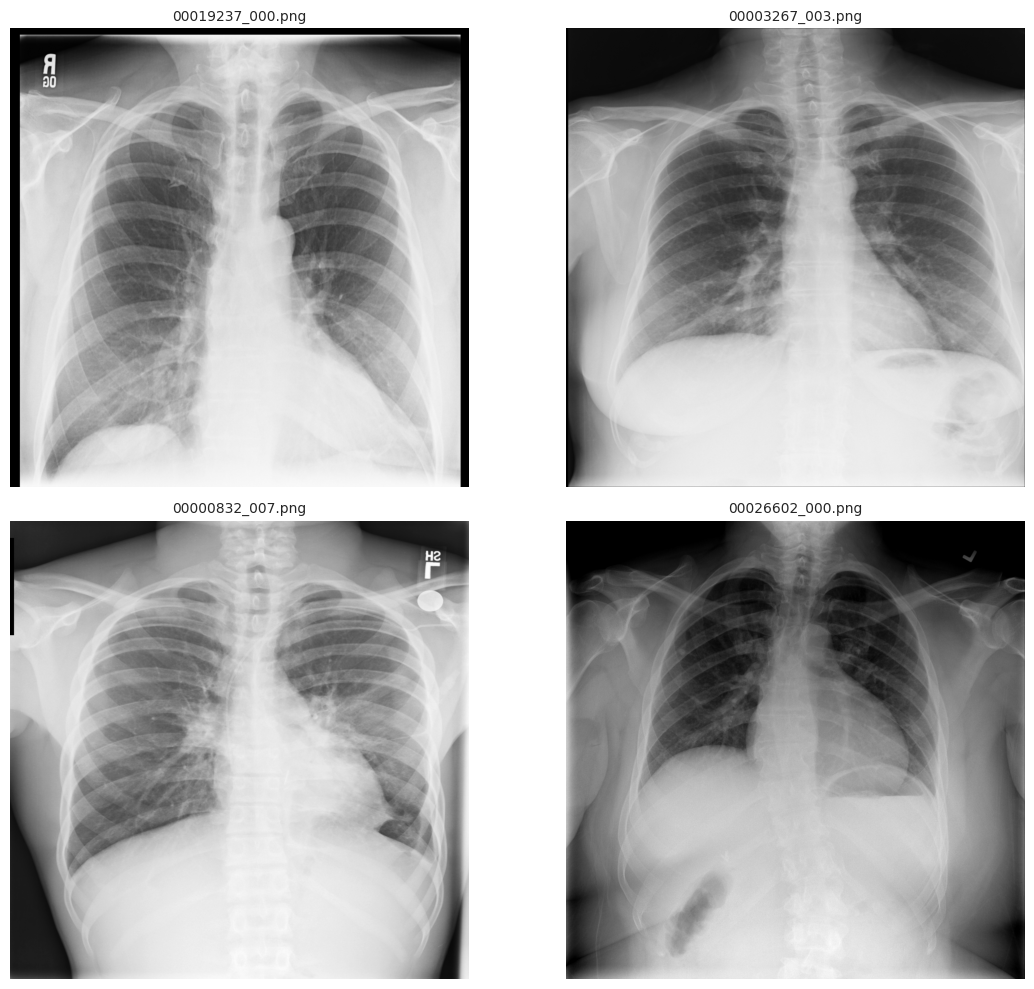

In [13]:
sample_images = random.sample(nih_images, 4)

plt.figure(figsize=(12, 10))

for i, img_path in enumerate(sample_images):

    img = Image.open(img_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(os.path.basename(img_path), fontsize=10)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
# Load NIH metadata

nih_df = pd.read_csv(NIH_METADATA)

print("NIH Metadata Loaded Successfully!")
print(f"Total Records : {len(nih_df):,}")

NIH Metadata Loaded Successfully!
Total Records : 112,120


In [15]:
# Display first five rows

nih_df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
0,00000001_000.png,Cardiomegaly,0,1,57,M,PA,2682,2749,0.143,0.143
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168
3,00000002_000.png,No Finding,0,2,80,M,PA,2500,2048,0.171,0.171
4,00000003_001.png,Hernia,0,3,74,F,PA,2500,2048,0.168,0.168


In [16]:
print("=" * 50)
print("Dataset Information")
print("=" * 50)

nih_df.info()

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112120 entries, 0 to 112119
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112120 non-null  object 
 1   Finding Labels               112120 non-null  object 
 2   Follow-up #                  112120 non-null  int64  
 3   Patient ID                   112120 non-null  int64  
 4   Patient Age                  112120 non-null  int64  
 5   Patient Sex                  112120 non-null  object 
 6   View Position                112120 non-null  object 
 7   OriginalImage[Width          112120 non-null  int64  
 8   Height]                      112120 non-null  int64  
 9   OriginalImagePixelSpacing[x  112120 non-null  float64
 10  y]                           112120 non-null  float64
dtypes: float64(2), int64(5), object(4)
memory usage: 9.4+ MB


In [17]:
print("=" * 50)
print("Statistical Summary")
print("=" * 50)

nih_df.describe(include="all")

Statistical Summary


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Sex,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y]
count,112120,112120,112120.000000,112120.000000,112120.000000,112120,112120,112120.000000,112120.000000,112120.000000,112120.000000
unique,112120,836,NaN,NaN,NaN,2,2,NaN,NaN,NaN,NaN
top,00000001_000.png,No Finding,NaN,NaN,NaN,M,PA,NaN,NaN,NaN,NaN
freq,1,60361,NaN,NaN,NaN,63340,67310,NaN,NaN,NaN,NaN
mean,NaN,NaN,8.573751,14346.381743,46.626365,NaN,NaN,2646.078844,2486.438842,0.155649,0.155649
std,NaN,NaN,15.406320,8403.876972,16.602680,NaN,NaN,341.246429,401.268227,0.016174,0.016174
min,NaN,NaN,0.000000,1.000000,0.000000,NaN,NaN,1143.000000,966.000000,0.115000,0.115000
25%,NaN,NaN,0.000000,7310.750000,34.000000,NaN,NaN,2500.000000,2048.000000,0.143000,0.143000
50%,NaN,NaN,3.000000,13993.000000,49.000000,NaN,NaN,2518.000000,2544.000000,0.143000,0.143000
75%,NaN,NaN,10.000000,20673.000000,59.000000,NaN,NaN,2992.000000,2991.000000,0.168000,0.168000


In [18]:
missing_values = nih_df.isnull().sum()

missing_values = missing_values[missing_values > 0]

print("Missing Values:\n")
print(missing_values)

Missing Values:

Series([], dtype: int64)


In [19]:
print("Columns in NIH Dataset:\n")

for column in nih_df.columns:
    print(column)

Columns in NIH Dataset:

Image Index
Finding Labels
Follow-up #
Patient ID
Patient Age
Patient Sex
View Position
OriginalImage[Width
Height]
OriginalImagePixelSpacing[x
y]


In [20]:
print(f"Rows    : {nih_df.shape[0]:,}")
print(f"Columns : {nih_df.shape[1]}")

Rows    : 112,120
Columns : 11


In [21]:
nih_df["View Position"].value_counts()

View Position
PA    67310
AP    44810
Name: count, dtype: int64

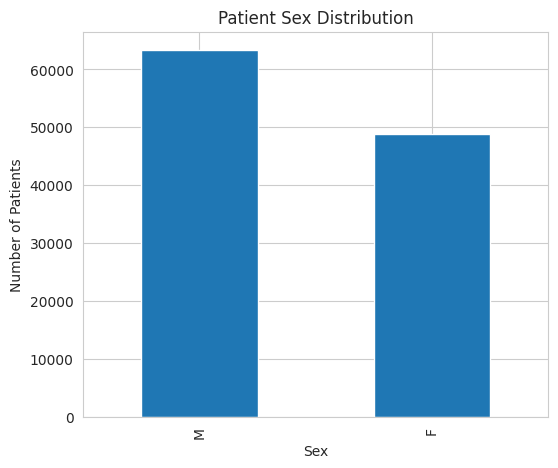

In [24]:
plt.figure(figsize=(6,5))

nih_df["Patient Sex"].value_counts().plot(kind="bar")

plt.title("Patient Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.show()

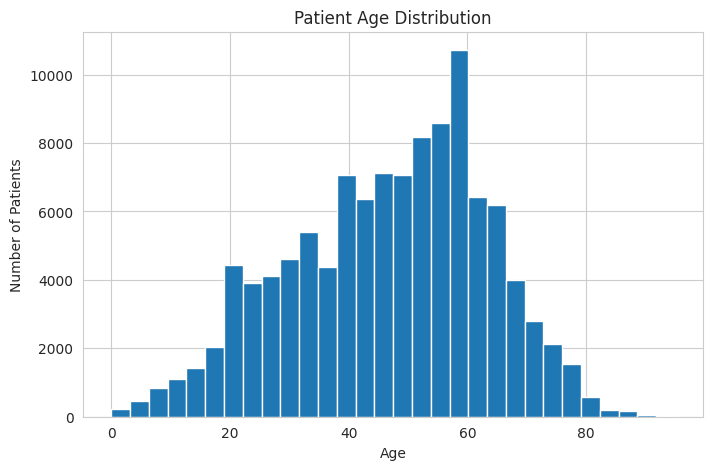

In [25]:
plt.figure(figsize=(8,5))

plt.hist(nih_df["Patient Age"], bins=30)

plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [26]:
nih_df["Finding Labels"].head(10)

0              Cardiomegaly
1    Cardiomegaly|Emphysema
2     Cardiomegaly|Effusion
3                No Finding
4                    Hernia
5                    Hernia
6       Hernia|Infiltration
7                    Hernia
8                    Hernia
9                    Hernia
Name: Finding Labels, dtype: object

In [27]:
# Display first 10 disease labels

nih_df["Finding Labels"].head(10)

0              Cardiomegaly
1    Cardiomegaly|Emphysema
2     Cardiomegaly|Effusion
3                No Finding
4                    Hernia
5                    Hernia
6       Hernia|Infiltration
7                    Hernia
8                    Hernia
9                    Hernia
Name: Finding Labels, dtype: object

In [28]:
# Count number of diseases in each image

nih_df["Number of Diseases"] = nih_df["Finding Labels"].apply(
    lambda x: len(x.split("|"))
)

nih_df["Number of Diseases"].value_counts().sort_index()

Number of Diseases
1    91324
2    14306
3     4856
4     1247
5      301
6       67
7       16
8        1
9        2
Name: count, dtype: int64

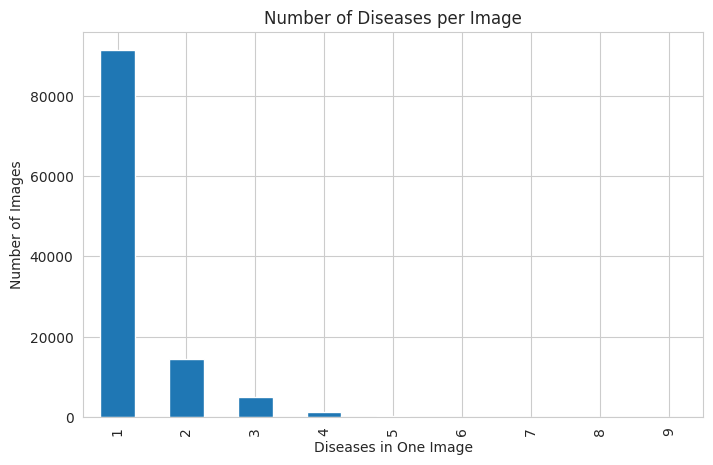

In [29]:
plt.figure(figsize=(8,5))

nih_df["Number of Diseases"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Diseases per Image")
plt.xlabel("Diseases in One Image")
plt.ylabel("Number of Images")

plt.show()

In [30]:
# Create one big list of all diseases

all_diseases = []

for labels in nih_df["Finding Labels"]:
    all_diseases.extend(labels.split("|"))

print("Total Disease Labels:", len(all_diseases))

Total Disease Labels: 141537


In [31]:
from collections import Counter

disease_counts = Counter(all_diseases)

disease_df = pd.DataFrame(
    disease_counts.items(),
    columns=["Disease", "Count"]
)

disease_df = disease_df.sort_values(
    by="Count",
    ascending=False
)

disease_df.reset_index(drop=True, inplace=True)

disease_df

,Disease,Count
0,No Finding,60361
1,Infiltration,19894
2,Effusion,13317
3,Atelectasis,11559
4,Nodule,6331
5,Mass,5782
6,Pneumothorax,5302
7,Consolidation,4667
8,Pleural_Thickening,3385
9,Cardiomegaly,2776


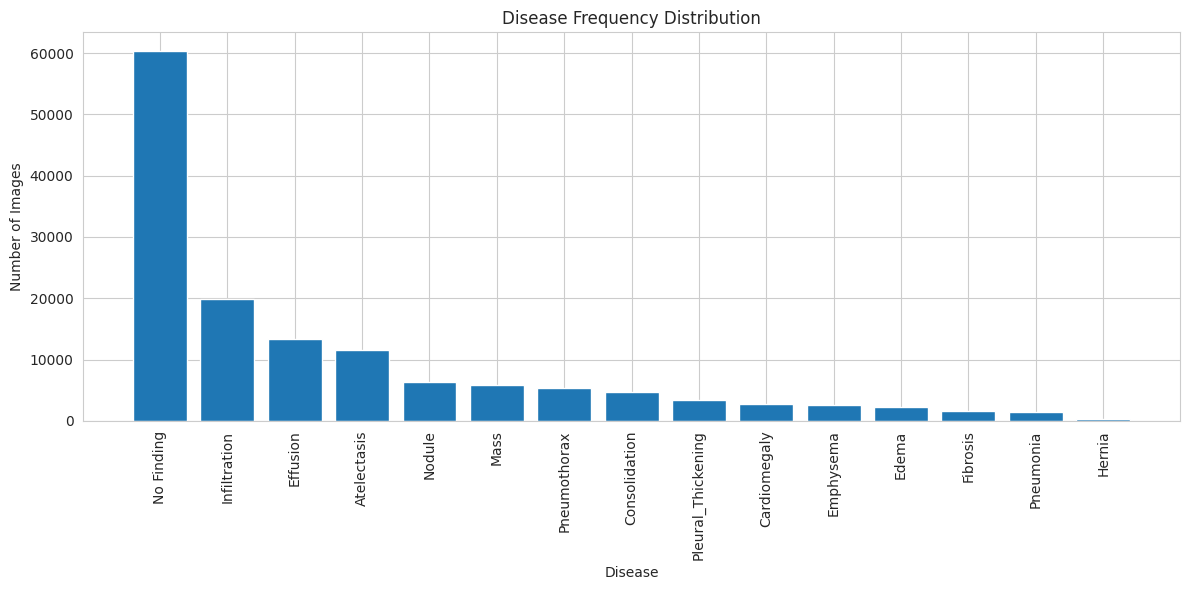

In [32]:
plt.figure(figsize=(12,6))

plt.bar(
    disease_df["Disease"],
    disease_df["Count"]
)

plt.xticks(rotation=90)

plt.title("Disease Frequency Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()

In [33]:
print("Top 10 Most Common Diseases\n")

disease_df.head(10)

Top 10 Most Common Diseases



,Disease,Count
0,No Finding,60361
1,Infiltration,19894
2,Effusion,13317
3,Atelectasis,11559
4,Nodule,6331
5,Mass,5782
6,Pneumothorax,5302
7,Consolidation,4667
8,Pleural_Thickening,3385
9,Cardiomegaly,2776


In [34]:
no_finding = (
    nih_df["Finding Labels"] == "No Finding"
).sum()

print("Images with No Finding:", no_finding)

Images with No Finding: 60361


In [35]:
disease_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "nih_disease_statistics.csv"
    ),
    index=False
)

print("Disease statistics saved successfully!")

Disease statistics saved successfully!


In [36]:
nih_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "nih_metadata.csv"
    ),
    index=False
)

print("NIH metadata saved successfully!")

NIH metadata saved successfully!


In [37]:
import os

print(os.listdir(OUTPUT_DIR))

['nih_disease_statistics.csv', 'nih_metadata.csv']


In [38]:
pd.read_csv(os.path.join(OUTPUT_DIR, "nih_disease_statistics.csv")).head()

,Disease,Count
0,No Finding,60361
1,Infiltration,19894
2,Effusion,13317
3,Atelectasis,11559
4,Nodule,6331


In [39]:
print("="*50)
print("Notebook 1 Sanity Check")
print("="*50)

print("✓ NIH Metadata Loaded :", len(nih_df))

print("✓ Total NIH Images :", len(nih_images))

print("✓ Disease Statistics :", len(disease_df))

print("✓ Metadata Saved :", os.path.exists(os.path.join(OUTPUT_DIR, "nih_metadata.csv")))

print("✓ Disease CSV Saved :", os.path.exists(os.path.join(OUTPUT_DIR, "nih_disease_statistics.csv")))

Notebook 1 Sanity Check
✓ NIH Metadata Loaded : 112120
✓ Total NIH Images : 112120
✓ Disease Statistics : 15
✓ Metadata Saved : True
✓ Disease CSV Saved : True


In [40]:
print("="*60)
print("IU-Xray Dataset Summary")
print("="*60)

iu_images = glob.glob(os.path.join(IU_IMAGE_DIR, "*.png"))
iu_xml_files = glob.glob(os.path.join(IU_XML_DIR, "*.xml"))

print(f"Total Images      : {len(iu_images):,}")
print(f"Total XML Reports : {len(iu_xml_files):,}")

IU-Xray Dataset Summary
Total Images      : 7,470
Total XML Reports : 3,955


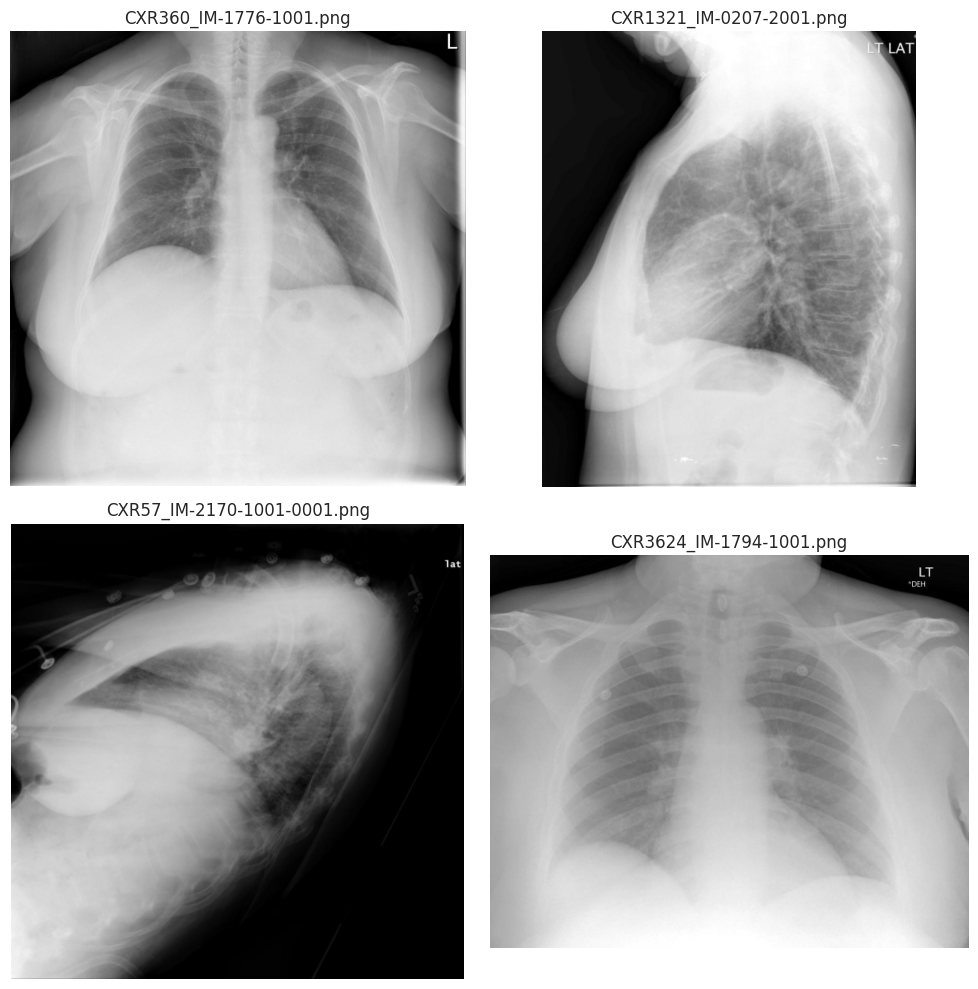

In [41]:
sample_imgs = random.sample(iu_images, 4)

plt.figure(figsize=(10,10))

for i, img_path in enumerate(sample_imgs):

    img = Image.open(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img, cmap="gray")

    plt.title(os.path.basename(img_path))

    plt.axis("off")

plt.tight_layout()

plt.show()

In [42]:
sample_xml = random.choice(iu_xml_files)

print("Sample XML File:")
print(sample_xml)

Sample XML File:
/kaggle/input/datasets/biditdas06/iu-x-ray/nlm_cxr_reports/ecgen-radiology/3513.xml


In [43]:
tree = ET.parse(sample_xml)
root = tree.getroot()

print("Root Tag :", root.tag)

Root Tag : eCitation


In [44]:
for child in root:
    print(child.tag)

meta
uId
pmcId
docSource
IUXRId
licenseType
licenseURL
ccLicense
articleURL
articleDate
articleType
publisher
title
note
specialty
subset
MedlineCitation
MeSH
parentImage


In [45]:
# Explore the MedlineCitation tag

for child in root.find("MedlineCitation"):
    print(child.tag)

Article
EssieArticleTitle
IMedAuthor
IMedAuthor


In [46]:
# Explore deeper if Article exists

medline = root.find("MedlineCitation")

article = medline.find("Article")

if article is not None:
    print("Article Found!\n")

    for child in article:
        print(child.tag)

else:
    print("No Article tag found.")

Article Found!

Journal
ArticleTitle
Abstract
Affiliation
AuthorList
Language
PublicationTypeList
ArticleDate


In [47]:
article = root.find("MedlineCitation").find("Article")

abstract = article.find("Abstract")

if abstract is not None:
    print("Abstract Found!\n")

    for child in abstract:
        print("Tag      :", child.tag)
        print("Label    :", child.attrib)
        print("Text     :", child.text)
        print("-"*60)

else:
    print("No Abstract Found.")

Abstract Found!

Tag      : AbstractText
Label    : {'Label': 'COMPARISON'}
Text     : XXXX.
------------------------------------------------------------
Tag      : AbstractText
Label    : {'Label': 'INDICATION'}
Text     : XXXX-year-old with shortness of breath.
------------------------------------------------------------
Tag      : AbstractText
Label    : {'Label': 'FINDINGS'}
Text     : Heart size and mediastinal contours appear within normal limits. Pulmonary vascularity is within normal limits. No focal consolidation, suspicious pulmonary opacity, pneumothorax or definite pleural effusion. Visualized osseous structures appear intact.
------------------------------------------------------------
Tag      : AbstractText
Label    : {'Label': 'IMPRESSION'}
Text     : No acute cardiopulmonary abnormality.
------------------------------------------------------------


In [48]:
parent_image = root.find("parentImage")

if parent_image is not None:
    print("parentImage Found!\n")

    for child in parent_image:
        print(child.tag, ":", child.text)

else:
    print("parentImage tag not found.")

parentImage Found!

figureId : F1
caption : PA and Lateral Chest. XXXX, XXXX XXXX PM . 
panel : 
         
         
         


In [49]:
parent_image = root.find("parentImage")

print(parent_image.attrib)

{'id': 'CXR3513_IM-1715-1001'}


In [50]:
import xml.etree.ElementTree as ET

tree = ET.parse(sample_xml)
root = tree.getroot()

ET.dump(root)

<eCitation>
   <meta type="rr" />
   <uId id="CXR3513" />
   <pmcId id="3513" />
   <docSource>CXR</docSource>
   <IUXRId id="3513" />
   <licenseType>open-access</licenseType>
   <licenseURL>http://creativecommons.org/licenses/by-nc-nd/4.0/</licenseURL>
   <ccLicense>byncnd</ccLicense>
   <articleURL />
   <articleDate>2013-08-01</articleDate>
   <articleType>XR</articleType>
   <publisher>Indiana University</publisher>
   <title>Indiana University Chest X-ray Collection</title>
   <note>The data are drawn from multiple hospital systems.</note>
   <specialty>pulmonary diseases</specialty>
   <subset>CXR</subset>
   <MedlineCitation Owner="Indiana University" Status="supplied by publisher">
   
      <Article PubModel="Electronic">
      
         <Journal>
         
            <JournalIssue>
            
               <PubDate>
               
                  <Year>2013</Year>
               
                  <Month>08</Month>
               
                  <Day>01</Day>
     

In [51]:
records = []

for xml_file in iu_xml_files:

    tree = ET.parse(xml_file)
    root = tree.getroot()

    image_id = ""

    findings = ""

    impression = ""

    indication = ""

    comparison = ""

    article_title = ""

    mesh_terms = ""

    # -----------------------
    # Image ID
    # -----------------------

    parent = root.find("parentImage")

    if parent is not None:

        image_id = parent.attrib.get("id", "") + ".png"

    # -----------------------
    # Article
    # -----------------------

    medline = root.find("MedlineCitation")

    if medline is not None:

        article = medline.find("Article")

        if article is not None:

            title = article.find("ArticleTitle")

            if title is not None:

                article_title = title.text

            abstract = article.find("Abstract")

            if abstract is not None:

                for section in abstract.findall("AbstractText"):

                    label = section.attrib.get("Label", "")

                    text = section.text if section.text else ""

                    if label == "FINDINGS":

                        findings = text

                    elif label == "IMPRESSION":

                        impression = text

                    elif label == "INDICATION":

                        indication = text

                    elif label == "COMPARISON":

                        comparison = text

    # -----------------------
    # MeSH
    # -----------------------

    mesh = root.find("MeSH")

    if mesh is not None:

        mesh_terms = ", ".join(

            [child.text for child in mesh if child.text]

        )

    # -----------------------

    records.append({

        "image_name": image_id,

        "findings": findings,

        "impression": impression,

        "indication": indication,

        "comparison": comparison,

        "mesh_terms": mesh_terms,

        "article_title": article_title

    })

In [52]:
iu_df = pd.DataFrame(records)

print("Total Reports :", len(iu_df))

iu_df.head()

Total Reports : 3955


,image_name,findings,impression,indication,comparison,mesh_terms,article_title
0,CXR3468_IM-1684-0001-0001.png,Heart size is at the upper limits of normal. T...,1. No focal airspace consolidation. 2. Emphyse...,"XXXX-year-old male, preoperative evaluation fo...",XXXX,"Atherosclerosis/aorta, Lung/hyperdistention, O...",Indiana University Chest X-ray Collection
1,CXR1853_IM-0555-1001.png,"The lungs are clear bilaterally. Specifically,...",No acute cardiopulmonary abnormality.,XXXX-year-old woman with left-sided chest pain...,None.,normal,Indiana University Chest X-ray Collection
2,CXR1317_IM-0205-1001.png,Lungs are clear. There is minimal atelectasis ...,"Minimal atelectasis left base, no acute abnorm...","The left lateral rib pain, XXXX, gunshot wound...",None,"Pulmonary Atelectasis/base/left/mild, Foreign ...",Indiana University Chest X-ray Collection
3,CXR1159_IM-0107-1001.png,Lungs are clear. There is no pneumothorax or p...,No acute cardiopulmonary process.,Chest pain.,XXXX,normal,Indiana University Chest X-ray Collection
4,CXR2803_IM-1234-1001.png,There are low lung volumes. The cardiac silhou...,No acute cardiopulmonary process.,Chest pain,,Lung/hypoinflation,Indiana University Chest X-ray Collection


In [53]:
print("="*50)

print("Missing Findings :", (iu_df["findings"]=="").sum())

print("Missing Impression :", (iu_df["impression"]=="").sum())

print("Missing Images :", (iu_df["image_name"]=="").sum())

print("="*50)

Missing Findings : 530
Missing Impression : 34
Missing Images : 104


In [54]:
iu_df["findings_length"] = iu_df["findings"].apply(len)

iu_df["impression_length"] = iu_df["impression"].apply(len)

iu_df[["findings_length","impression_length"]].describe()

,findings_length,impression_length
count,3955.000000,3955.000000
mean,191.125411,76.880910
std,118.940133,83.371955
min,0.000000,0.000000
25%,120.000000,33.000000
50%,188.000000,40.000000
75%,257.000000,90.000000
max,1054.000000,887.000000


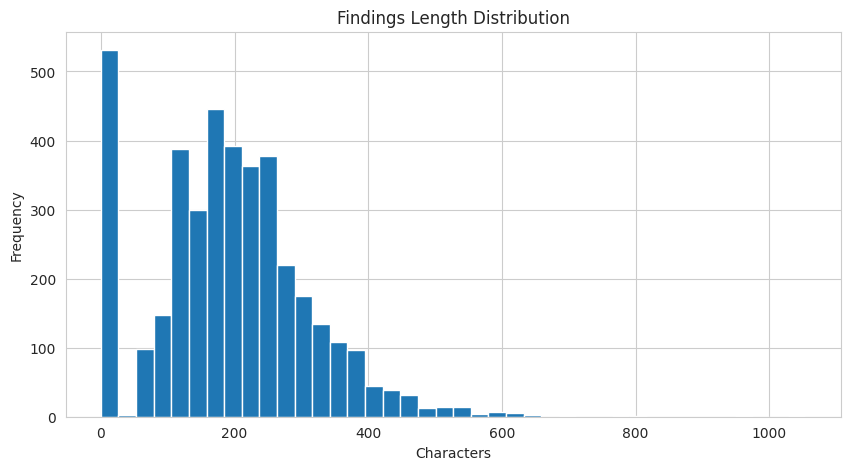

In [55]:
plt.figure(figsize=(10,5))

plt.hist(iu_df["findings_length"], bins=40)

plt.title("Findings Length Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [56]:
iu_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "iu_metadata.csv"

    ),

    index=False

)

In [57]:
iu_df[

    [

        "image_name",

        "findings",

        "impression"

    ]

].to_csv(

    os.path.join(

        OUTPUT_DIR,

        "iu_reports.csv"

    ),

    index=False

)

print("IU metadata saved successfully!")

IU metadata saved successfully!


In [58]:
# Load COVIDx metadata files

covid_train = pd.read_csv(
    COVID_TRAIN_TXT,
    sep=" ",
    header=None,
    names=["patient_id", "filename", "label", "source"]
)

covid_val = pd.read_csv(
    COVID_VAL_TXT,
    sep=" ",
    header=None,
    names=["patient_id", "filename", "label", "source"]
)

covid_test = pd.read_csv(
    COVID_TEST_TXT,
    sep=" ",
    header=None,
    names=["patient_id", "filename", "label", "source"]
)

print("COVIDx metadata loaded successfully!")

COVIDx metadata loaded successfully!


In [59]:
print("="*50)
print("COVIDx Dataset Summary")
print("="*50)

print("Train Images :", len(covid_train))
print("Validation Images :", len(covid_val))
print("Test Images :", len(covid_test))

COVIDx Dataset Summary
Train Images : 67863
Validation Images : 8473
Test Images : 8482


In [60]:
covid_train.head()

,patient_id,filename,label,source
0,379,1e64990d1b40c1758a2aaa9c7f7a85_jumbo.jpeg,negative,cohen
1,379,7223b8ad031187d9a142d7f7ca02c9_jumbo.jpeg,negative,cohen
2,380,3392dc7d262e28423caca517f98c2e_jumbo.jpeg,negative,cohen
3,380,ec3a480c0926ded74429df416cfb05_jumbo.jpeg,negative,cohen
4,382,a72aeb349a63c79ed24e473c434efe_jumbo.jpg,negative,cohen


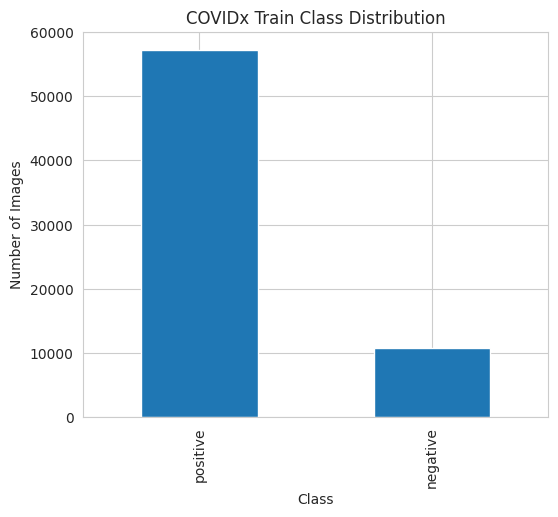

In [61]:
plt.figure(figsize=(6,5))

covid_train["label"].value_counts().plot(kind="bar")

plt.title("COVIDx Train Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

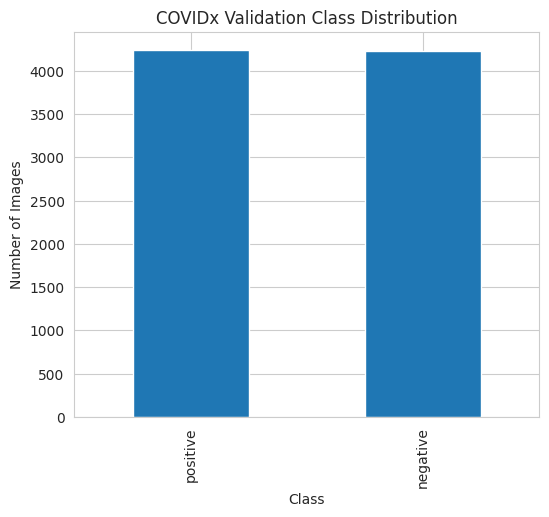

In [62]:
plt.figure(figsize=(6,5))

covid_val["label"].value_counts().plot(kind="bar")

plt.title("COVIDx Validation Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

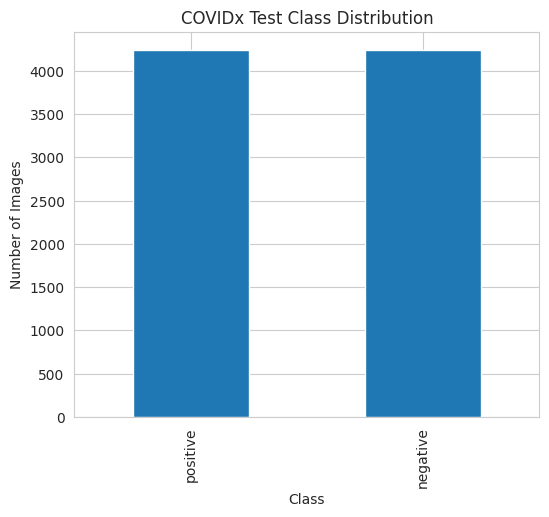

In [63]:
plt.figure(figsize=(6,5))

covid_test["label"].value_counts().plot(kind="bar")

plt.title("COVIDx Test Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

plt.show()

In [64]:
covid_train["split"] = "train"
covid_val["split"] = "validation"
covid_test["split"] = "test"

covid_df = pd.concat(
    [covid_train, covid_val, covid_test],
    ignore_index=True
)

covid_df.to_csv(
    os.path.join(OUTPUT_DIR, "covidx_metadata.csv"),
    index=False
)

print("COVIDx metadata saved successfully!")

COVIDx metadata saved successfully!


In [65]:
summary_df = pd.DataFrame({
    "Dataset": [
        "NIH ChestXray14",
        "IU-Xray",
        "COVIDx"
    ],
    "Images": [
        len(nih_images),
        len(iu_images),
        len(covid_df)
    ],
    "Reports": [
        "No",
        len(iu_df),
        "No"
    ],
    "Primary Purpose": [
        "Disease Classification",
        "Report Generation",
        "COVID Classification"
    ]
})

summary_df

,Dataset,Images,Reports,Primary Purpose
0,NIH ChestXray14,112120,No,Disease Classification
1,IU-Xray,7470,3955,Report Generation
2,COVIDx,84818,No,COVID Classification


In [66]:
summary_df.to_csv(
    os.path.join(OUTPUT_DIR, "dataset_summary.csv"),
    index=False
)

print("Dataset summary saved successfully!")

Dataset summary saved successfully!


In [67]:
print("="*60)
print("Generated Files")
print("="*60)

for file in os.listdir(OUTPUT_DIR):
    print("✓", file)

Generated Files
✓ nih_disease_statistics.csv
✓ iu_metadata.csv
✓ covidx_metadata.csv
✓ iu_reports.csv
✓ dataset_summary.csv
✓ nih_metadata.csv


In [68]:
print("="*60)
print("NOTEBOOK 1 COMPLETED")
print("="*60)

print(f"NIH Images              : {len(nih_images):,}")
print(f"IU Images               : {len(iu_images):,}")
print(f"IU Reports              : {len(iu_df):,}")
print(f"COVID Images            : {len(covid_df):,}")

print("\nGenerated Files:")

for file in os.listdir(OUTPUT_DIR):
    print("✓", file)

print("\nNotebook 2 will use these CSV files directly.")

NOTEBOOK 1 COMPLETED
NIH Images              : 112,120
IU Images               : 7,470
IU Reports              : 3,955
COVID Images            : 84,818

Generated Files:
✓ nih_disease_statistics.csv
✓ iu_metadata.csv
✓ covidx_metadata.csv
✓ iu_reports.csv
✓ dataset_summary.csv
✓ nih_metadata.csv

Notebook 2 will use these CSV files directly.


In [69]:
with open(COVID_TRAIN_TXT, "r") as f:
    for i in range(5):
        print(f.readline())

379 1e64990d1b40c1758a2aaa9c7f7a85_jumbo.jpeg negative cohen

379 7223b8ad031187d9a142d7f7ca02c9_jumbo.jpeg negative cohen

380 3392dc7d262e28423caca517f98c2e_jumbo.jpeg negative cohen

380 ec3a480c0926ded74429df416cfb05_jumbo.jpeg negative cohen

382 a72aeb349a63c79ed24e473c434efe_jumbo.jpg negative cohen



In [70]:
print("=" * 60)
print("NOTEBOOK 1 - FINAL CHECK")
print("=" * 60)

files = os.listdir(OUTPUT_DIR)

expected_files = [
    "nih_metadata.csv",
    "nih_disease_statistics.csv",
    "iu_metadata.csv",
    "iu_reports.csv",
    "covidx_metadata.csv",
    "dataset_summary.csv"
]

for file in expected_files:
    if file in files:
        print(f"✅ {file}")
    else:
        print(f"❌ {file}")

print("\nTotal Generated Files:", len(files))

NOTEBOOK 1 - FINAL CHECK
✅ nih_metadata.csv
✅ nih_disease_statistics.csv
✅ iu_metadata.csv
✅ iu_reports.csv
✅ covidx_metadata.csv
✅ dataset_summary.csv

Total Generated Files: 6
